In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import cv2

# 1. Load the Malaria Dataset
print("Downloading and loading dataset...")
dataset, info = tfds.load('malaria', split=['train[:80%]', 'train[80%:]'], with_info=True, as_supervised=True)
train_dataset, val_dataset = dataset

# 2. Preprocess the images
IMG_SIZE = 128

def preprocess(image, label):
    # Resize to 128x128 and normalize pixel values to [0, 1]
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

# Optimize data pipelines
BATCH_SIZE = 32
train_ds = train_dataset.map(preprocess).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_dataset.map(preprocess).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Dataset loaded and preprocessed successfully!")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.Y4V4RR_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.
Dataset loaded and preprocessed successfully!


In [2]:
# 3. Build the CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # This is the target layer for our Grad-CAM
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', name='last_conv_layer'),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    # Sigmoid activation for binary classification (0 = Parasitized, 1 = Uninfected)
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# 4. Train the model (5 epochs should yield ~93% accuracy)
print("Starting training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.7629 - loss: 0.4625 - val_accuracy: 0.9220 - val_loss: 0.2204
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9283 - loss: 0.2115 - val_accuracy: 0.9361 - val_loss: 0.1969
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9377 - loss: 0.1879 - val_accuracy: 0.9458 - val_loss: 0.1716
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9447 - loss: 0.1714 - val_accuracy: 0.9507 - val_loss: 0.1699
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9492 - loss: 0.1650 - val_accuracy: 0.9537 - val_loss: 0.1652


In [3]:
# 5. Fetch a single Parasitized cell from the validation set
# In this dataset: 0 = Parasitized, 1 = Uninfected
test_img = None
test_label = None

for images, labels in val_ds.unbatch().take(100):
    if labels.numpy() == 0:
        test_img = images.numpy()
        test_label = labels.numpy()
        break

# Expand dimensions to fit the model input shape (1, 128, 128, 3)
img_array = np.expand_dims(test_img, axis=0)

# Get the model's prediction
prediction = model.predict(img_array)[0][0]
pred_class = "Uninfected" if prediction > 0.5 else "Parasitized"
confidence = prediction if prediction > 0.5 else 1 - prediction

print(f"True Label: Parasitized")
print(f"Model Prediction: {pred_class} (Confidence: {confidence:.2%})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
True Label: Parasitized
Model Prediction: Parasitized (Confidence: 94.46%)


In [7]:
# --- XAI 1: GRAD-CAM ---
# For Sequential models in Keras 3, we build a new Functional model
# by traversing the layers to avoid the 'never been called' attribute error.

# Define a new functional model for Grad-CAM
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inputs
layer_outputs = {}

for layer in model.layers:
    x = layer(x)
    layer_outputs[layer.name] = x

# Create a sub-model that outputs both the target conv layer and the final prediction
grad_model = tf.keras.Model(inputs=inputs, outputs=[layer_outputs['last_conv_layer'], x])

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    # For binary classification (sigmoid), explain the scalar output
    loss = predictions[:, 0]

# Calculate gradients of the loss w.r.t the feature maps
grads = tape.gradient(loss, conv_outputs)

# Compute the weights by averaging the gradients spatially
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Multiply each feature map by its weight and sum them up
heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Apply ReLU and normalize
heatmap = tf.maximum(heatmap, 0)
max_heat = tf.math.reduce_max(heatmap)
if max_heat != 0:
    heatmap = heatmap / max_heat
heatmap = heatmap.numpy()

# --- XAI 2: SALIENCY MAP ---
# We can reuse the grad_model or the original model here
with tf.GradientTape() as tape:
    img_tensor = tf.cast(img_array, tf.float32)
    tape.watch(img_tensor)
    preds = model(img_tensor)
    loss_saliency = preds[:, 0]

saliency_grads = tape.gradient(loss_saliency, img_tensor)
saliency_map = tf.reduce_max(tf.abs(saliency_grads), axis=-1)[0]
saliency_map = saliency_map.numpy()

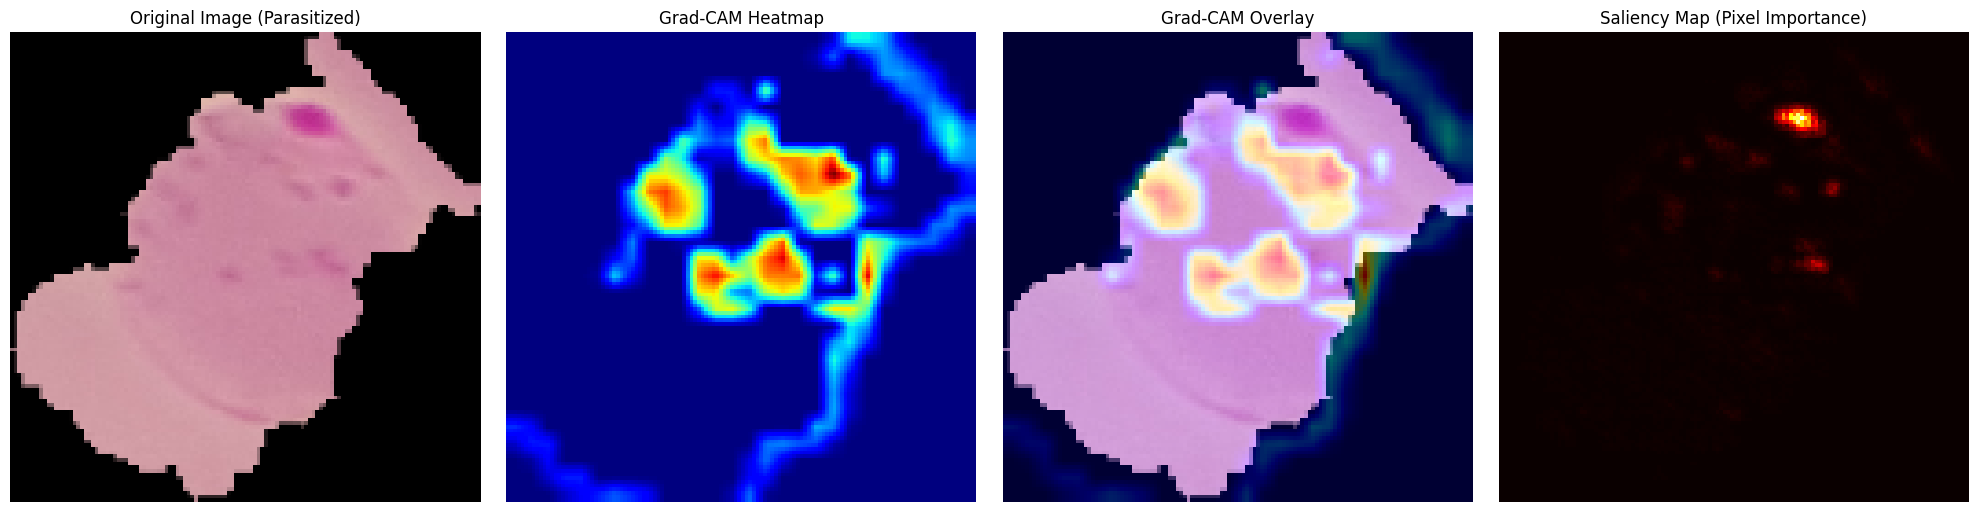

In [10]:
# Process Grad-CAM Heatmap for display
heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
heatmap_colored = np.float32(heatmap_colored) / 255.0

# Overlay heatmap on original image
# We clip to [0, 1] to avoid matplotlib warnings
superimposed_img = np.clip(heatmap_colored * 0.4 + test_img, 0, 1)

# Plotting the results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Original Image
axes[0].imshow(test_img)
axes[0].set_title('Original Image (Parasitized)')
axes[0].axis('off')

# 2. Grad-CAM Heatmap
axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')

# 3. Grad-CAM Overlay
axes[2].imshow(superimposed_img)
axes[2].set_title('Grad-CAM Overlay')
axes[2].axis('off')

# 4. Saliency Map
axes[3].imshow(saliency_map, cmap='hot')
axes[3].set_title('Saliency Map (Pixel Importance)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

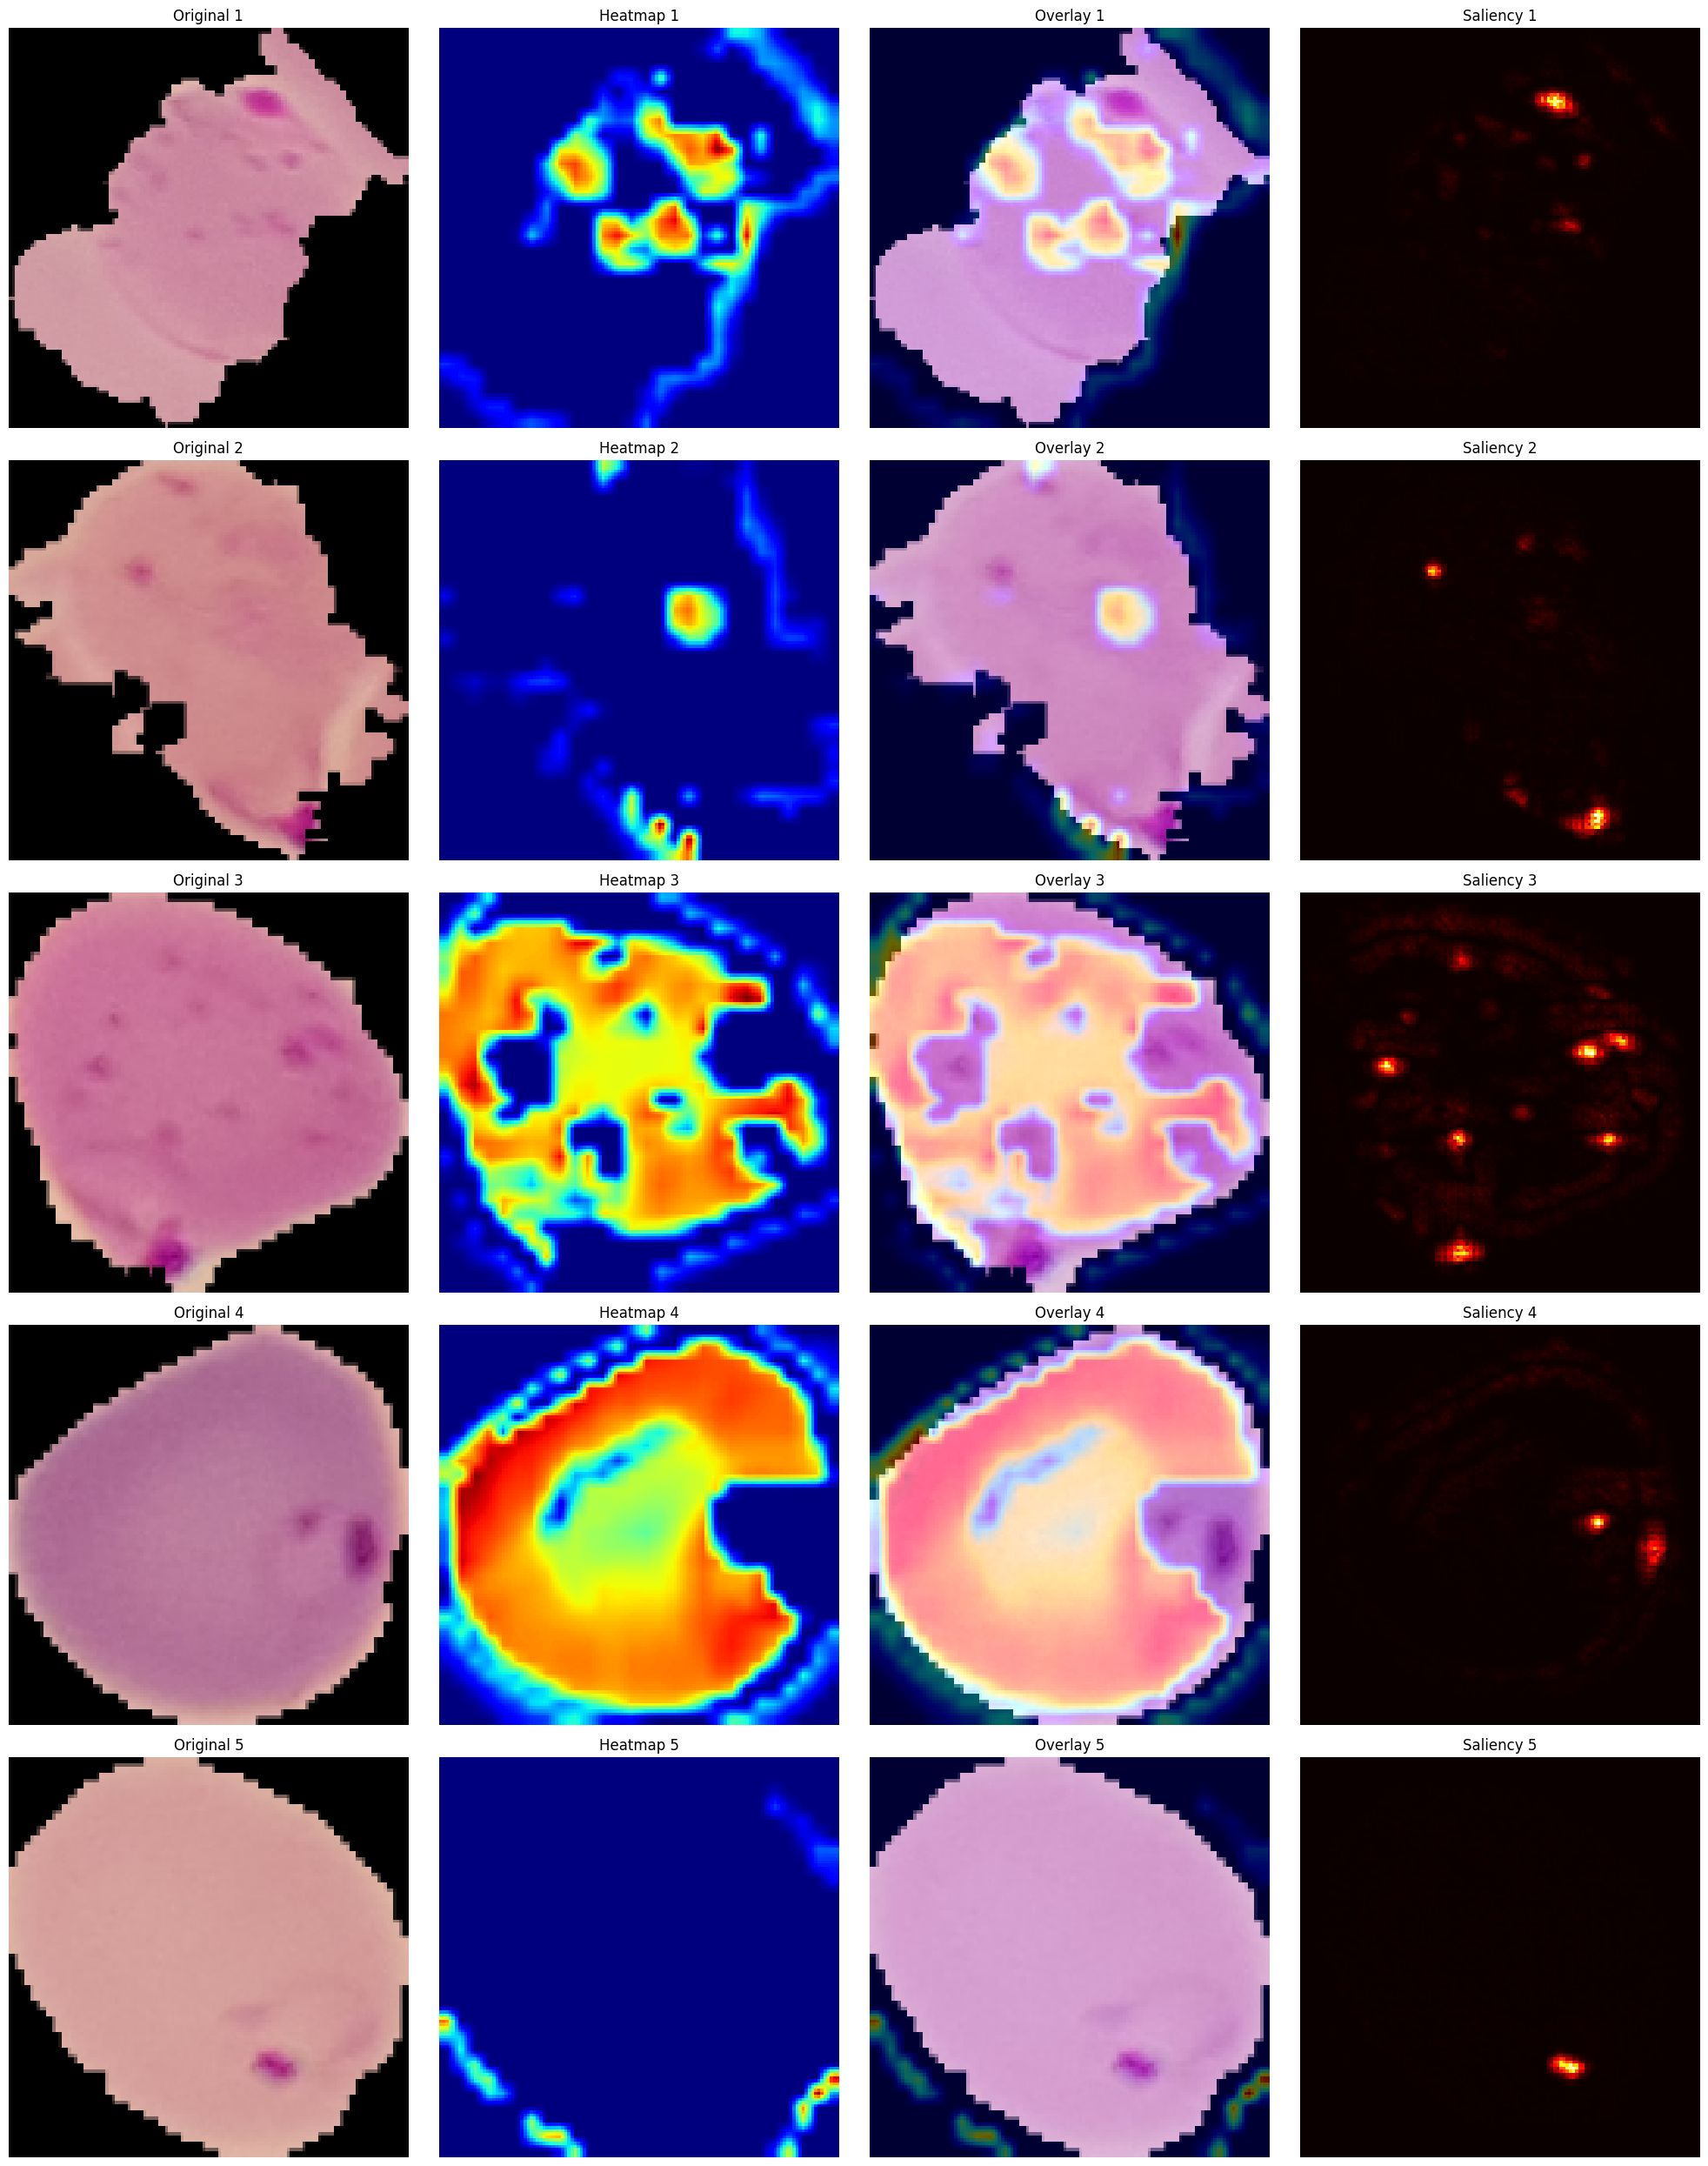

In [11]:
# 6. Comparison on multiple Parasitized cells
num_examples = 5
parasitized_images = []

# Fetch 'num_examples' parasitized cells
for images, labels in val_ds.unbatch():
    if labels.numpy() == 0: # 0 = Parasitized
        parasitized_images.append(images.numpy())
    if len(parasitized_images) >= num_examples:
        break

fig, axes = plt.subplots(num_examples, 4, figsize=(20, 5 * num_examples))

for i, img in enumerate(parasitized_images):
    img_batch = np.expand_dims(img, axis=0)

    # Grad-CAM
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) != 0:
        heatmap = heatmap / tf.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # Process Heatmap
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    heatmap_colored = np.float32(heatmap_colored) / 255.0
    superimposed = np.clip(heatmap_colored * 0.4 + img, 0, 1)

    # Saliency Map
    with tf.GradientTape() as tape:
        it = tf.cast(img_batch, tf.float32)
        tape.watch(it)
        p = model(it)
        l = p[:, 0]
    s_grads = tape.gradient(l, it)
    s_map = tf.reduce_max(tf.abs(s_grads), axis=-1)[0].numpy()

    # Plotting
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].set_title(f'Heatmap {i+1}')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(superimposed)
    axes[i, 2].set_title(f'Overlay {i+1}')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(s_map, cmap='hot')
    axes[i, 3].set_title(f'Saliency {i+1}')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()